# More Evaluations

In [1]:
import pandas as pd
from model_manager import classify

/home/theca/repos/GitHub/CodePath/AI201/ai201-project3-takemeter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 836.68it/s]


In [2]:
LABEL_TO_ID = {"artistic_critique": 0, "external_narrative": 1, "fandom_expression": 2}
test_df = pd.read_csv("./data/test.csv")

In [3]:
def label_order_confidences(confidences_dict):
    return sorted(confidences_dict.items(), key=lambda kv: LABEL_TO_ID[kv[0]])

## Section 1: Sample Classifications

In [4]:
sample = test_df.sample(n=5, random_state=42) # Added random_state for reproducibility

print("\nSample Classifications (Fine-Tuned DistilBERT):")
print("------------------------------------------")
for idx, row in sample.iterrows():
    id = row["id"]
    text = row["text"]
    true_label = row["label"]
    predicted_label, confidences = classify(text)

    # Format all confidences as a comma-separated string
    confidences_str = ', '.join([f'{c:.2f}' for _, c in label_order_confidences(confidences)])

    print(f"\nID: {id}")
    print(f"Text: {text[:150]}{'...' if len(text) > 150 else ''}")
    print(f"  True Label:      {true_label}")
    print(f"  Predicted Label: {predicted_label} {"✅" if true_label == predicted_label else "❌"}  (confidences: {confidences_str})")


Sample Classifications (Fine-Tuned DistilBERT):
------------------------------------------

ID: 179
Text: I'm already quaking
  True Label:      fandom_expression
  Predicted Label: fandom_expression ✅  (confidences: 0.36, 0.27, 0.37)

ID: 69
Text: NOT Future's verses are better than Taylor's I'm dead
  True Label:      fandom_expression
  Predicted Label: artistic_critique ❌  (confidences: 0.79, 0.11, 0.10)

ID: 130
Text: Hey Mama Day
  True Label:      fandom_expression
  Predicted Label: artistic_critique ❌  (confidences: 0.35, 0.31, 0.34)

ID: 89
Text: Does anyone know if the magazines are different or are they all the same inside material
  True Label:      external_narrative
  Predicted Label: external_narrative ✅  (confidences: 0.10, 0.79, 0.10)

ID: 38
Text: DANCING WITH OUR HANDS TIED IS A BANGERRRR
  True Label:      fandom_expression
  Predicted Label: artistic_critique ❌  (confidences: 0.59, 0.17, 0.25)


## Section 2: Confidence Calibration

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

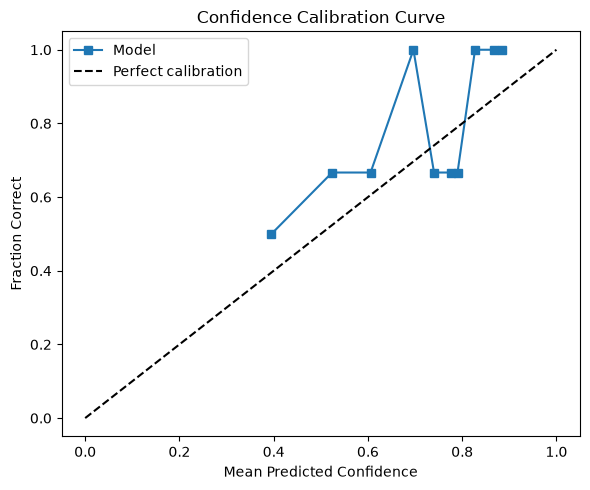

Overall accuracy: 0.781
Mean winning confidence: 0.706


In [6]:
# Run classify on all test samples, collecting predicted label, winning confidence, and correctness
pred_labels = []
win_confidences = []
correct = []

for _, row in test_df.iterrows():
    predicted_label, confidences = classify(row["text"])
    winning_conf = confidences[predicted_label]
    pred_labels.append(predicted_label)
    win_confidences.append(winning_conf)
    correct.append(int(predicted_label == row["label"]))

win_confidences = np.array(win_confidences)
correct = np.array(correct)

# Compute calibration curve: fraction of correct predictions per confidence bin
fraction_of_positives, mean_predicted_confidence = calibration_curve(
    correct, win_confidences, n_bins=10, strategy="quantile"
)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_predicted_confidence, fraction_of_positives, "s-", label="Model")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Confidence")
ax.set_ylabel("Fraction Correct")
ax.set_title("Confidence Calibration Curve")
ax.legend()
plt.tight_layout()
plt.savefig("./results/confidence_calibration.png", dpi=150)
plt.show()

print(f"Overall accuracy: {correct.mean():.3f}")
print(f"Mean winning confidence: {win_confidences.mean():.3f}")